In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import warnings

warnings.filterwarnings("ignore")
warnings.simplefilter("ignore", category=FutureWarning)
warnings.simplefilter("ignore", category=UserWarning)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", None)

In [2]:
# Project color palette

# Main project colors based on the selected visual identity
PROJECT_COLORS = {
    "black": "#000000",
    "dark_gray": "#4A4A4A",
    "green": "#00BF63",
    "primary_blue": "#024DC5",
    "bright_blue": "#0962EF",
    "deep_navy": "#050818",
    "muted_blue": "#3567A1",
    "soft_azure": "#5F8FB3",
    "light_azure": "#AED9F1",
    "light_gray": "#D2D2D2",
    "white": "#FFFFFF",
    "gradient_start": "#0370FF",
    "gradient_end": "#000E59"}

# General palette for non-cluster visuals
MAIN_PALETTE = [
    PROJECT_COLORS["primary_blue"],
    PROJECT_COLORS["green"],
    PROJECT_COLORS["deep_navy"],
    PROJECT_COLORS["bright_blue"],
    PROJECT_COLORS["light_gray"],
    PROJECT_COLORS["muted_blue"],
    PROJECT_COLORS["dark_gray"],
    PROJECT_COLORS["soft_azure"]]

# Stable cluster colors for clearer visual separation
CLUSTER_PALETTE = {
    0: PROJECT_COLORS["soft_azure"],   # lighter blue
    1: PROJECT_COLORS["green"],        # green
    2: PROJECT_COLORS["dark_gray"],    # dark gray
    3: PROJECT_COLORS["black"],        # black
    4: PROJECT_COLORS["primary_blue"], # strong blue
    5: PROJECT_COLORS["deep_navy"],    # navy
    -1: PROJECT_COLORS["light_gray"]}  # noise / secondary points


# Ordered list version of the cluster palette for convenience
CLUSTER_COLOR_LIST = [
    PROJECT_COLORS["soft_azure"],
    PROJECT_COLORS["green"],
    PROJECT_COLORS["dark_gray"],
    PROJECT_COLORS["black"],
    PROJECT_COLORS["primary_blue"],
    PROJECT_COLORS["deep_navy"]]

# Sequential blue colormap for heatmaps and intensity-based visuals
BLUE_CMAP = LinearSegmentedColormap.from_list(
    "project_blues",
    [
        PROJECT_COLORS["light_azure"],
        PROJECT_COLORS["soft_azure"],
        PROJECT_COLORS["muted_blue"],
        PROJECT_COLORS["primary_blue"],
        PROJECT_COLORS["deep_navy"]])

# ---------------------------------
# Global plot styling
# ---------------------------------

sns.set_theme(style="whitegrid", palette=MAIN_PALETTE)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["figure.titlesize"] = 16

plt.rcParams["axes.facecolor"] = PROJECT_COLORS["white"]
plt.rcParams["figure.facecolor"] = PROJECT_COLORS["white"]
plt.rcParams["savefig.facecolor"] = PROJECT_COLORS["white"]

plt.rcParams["axes.edgecolor"] = PROJECT_COLORS["light_gray"]
plt.rcParams["grid.color"] = PROJECT_COLORS["light_gray"]
plt.rcParams["text.color"] = PROJECT_COLORS["deep_navy"]
plt.rcParams["axes.labelcolor"] = PROJECT_COLORS["deep_navy"]
plt.rcParams["xtick.color"] = PROJECT_COLORS["deep_navy"]
plt.rcParams["ytick.color"] = PROJECT_COLORS["deep_navy"]

In [11]:
# Create a folder for saving plots inside the current analysis directory
FIGURES_DIR = Path("./figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
DATA_PATH = Path("../1. Data/Customer Data.csv")
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.9007,0.8182,95.4000,0.0000,95.4000,0.0000,0.1667,0.0000,0.0833,0.0000,0,2,"1,000.0000",201.8021,139.5098,0.0000,12
1,C10002,"3,202.4674",0.9091,0.0000,0.0000,0.0000,"6,442.9455",0.0000,0.0000,0.0000,0.2500,4,0,"7,000.0000","4,103.0326","1,072.3402",0.2222,12
2,C10003,"2,495.1489",1.0000,773.1700,773.1700,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0,12,"7,500.0000",622.0667,627.2848,0.0000,12
3,C10004,"1,666.6705",0.6364,"1,499.0000","1,499.0000",0.0000,205.7880,0.0833,0.0833,0.0000,0.0833,1,1,"7,500.0000",0.0000,NaN,0.0000,12
4,C10005,817.7143,1.0000,16.0000,16.0000,0.0000,0.0000,0.0833,0.0833,0.0000,0.0000,0,1,"1,200.0000",678.3348,244.7912,0.0000,12


In [4]:
print(df.columns.tolist())
df.info()

['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']
<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-nul

In [5]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
BALANCE,"8,950.0000","1,564.4748","2,081.5319",0.0000,128.2819,873.3852,"2,054.1400","19,043.1386"
BALANCE_FREQUENCY,"8,950.0000",0.8773,0.2369,0.0000,0.8889,1.0000,1.0000,1.0000
PURCHASES,"8,950.0000","1,003.2048","2,136.6348",0.0000,39.6350,361.2800,"1,110.1300","49,039.5700"
ONEOFF_PURCHASES,"8,950.0000",592.4374,"1,659.8879",0.0000,0.0000,38.0000,577.4050,"40,761.2500"
INSTALLMENTS_PURCHASES,"8,950.0000",411.0676,904.3381,0.0000,0.0000,89.0000,468.6375,"22,500.0000"
CASH_ADVANCE,"8,950.0000",978.8711,"2,097.1639",0.0000,0.0000,0.0000,"1,113.8211","47,137.2118"
PURCHASES_FREQUENCY,"8,950.0000",0.4904,0.4014,0.0000,0.0833,0.5000,0.9167,1.0000
ONEOFF_PURCHASES_FREQUENCY,"8,950.0000",0.2025,0.2983,0.0000,0.0000,0.0833,0.3000,1.0000
PURCHASES_INSTALLMENTS_FREQUENCY,"8,950.0000",0.3644,0.3974,0.0000,0.0000,0.1667,0.7500,1.0000
CASH_ADVANCE_FREQUENCY,"8,950.0000",0.1351,0.2001,0.0000,0.0000,0.0000,0.2222,1.5000


In [6]:
duplicate_rows = df.duplicated().sum()
duplicate_customer_ids = df["CUST_ID"].duplicated().sum()
missing_summary = (
    df.isna()
      .sum()
      .to_frame(name="missing_count")
      .assign(missing_pct=lambda x: (x["missing_count"] / len(df)) * 100)
      .sort_values("missing_count", ascending=False))
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
print(f"Duplicate rows: {duplicate_rows}")
print(f"Duplicate customer IDs: {duplicate_customer_ids}")
display(missing_summary)

Duplicate rows: 0
Duplicate customer IDs: 0


,missing_count,missing_pct
MINIMUM_PAYMENTS,313,3.4972
CREDIT_LIMIT,1,0.0112


In [8]:
# Calculate the percentage of zero values for each numeric feature
numeric_cols = df.drop(columns="CUST_ID").columns
zero_summary = (
    (df[numeric_cols] == 0)
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .to_frame(name="zero_pct"))
display(zero_summary)

,zero_pct
PRC_FULL_PAYMENT,65.9553
CASH_ADVANCE_FREQUENCY,51.7095
CASH_ADVANCE,51.7095
CASH_ADVANCE_TRX,51.7095
ONEOFF_PURCHASES_FREQUENCY,48.0670
ONEOFF_PURCHASES,48.0670
INSTALLMENTS_PURCHASES,43.7542
PURCHASES_INSTALLMENTS_FREQUENCY,43.7430
PURCHASES,22.8380
PURCHASES_TRX,22.8380


In [9]:
skewness_summary = (df[numeric_cols].skew().to_frame(name="skewness"))
# Add absolute skewness to rank features by intensity, regardless of sign
skewness_summary["abs_skewness"] = skewness_summary["skewness"].abs()
skewness_summary = skewness_summary.sort_values("abs_skewness", ascending=False)
display(skewness_summary)

,skewness,abs_skewness
MINIMUM_PAYMENTS,13.6228,13.6228
ONEOFF_PURCHASES,10.0451,10.0451
PURCHASES,8.1443,8.1443
INSTALLMENTS_PURCHASES,7.2991,7.2991
PAYMENTS,5.9076,5.9076
CASH_ADVANCE_TRX,5.7213,5.7213
CASH_ADVANCE,5.1666,5.1666
PURCHASES_TRX,4.6307,4.6307
TENURE,-2.9430,2.9430
BALANCE,2.3934,2.3934


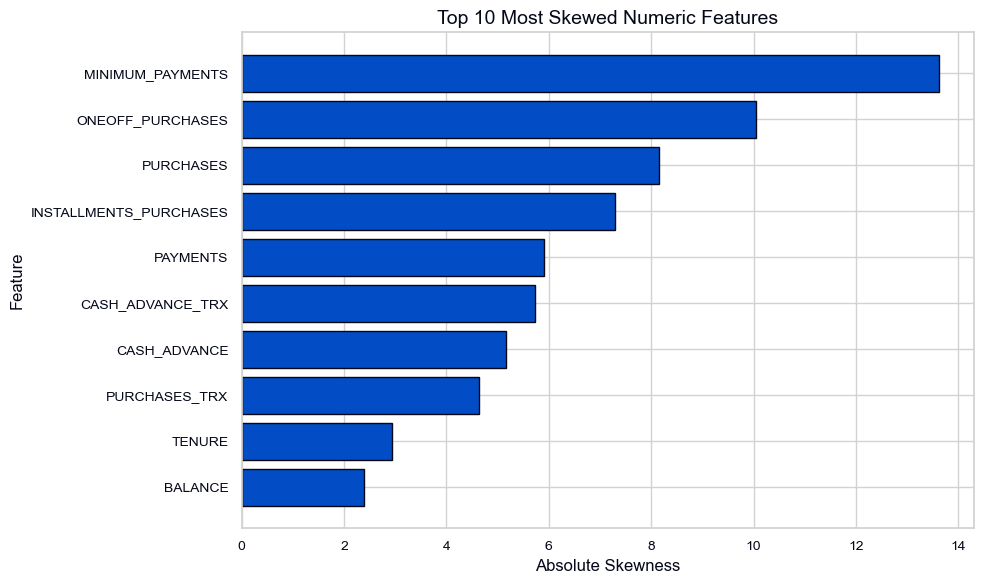

In [12]:
# Select the top 10 most skewed features
top_skewed = skewness_summary.head(10).sort_values("abs_skewness", ascending=True)
# Create a horizontal bar plot for the top skewed features
plt.figure(figsize=(10, 6))
plt.barh(
    y=top_skewed.index,
    width=top_skewed["abs_skewness"],
    color=PROJECT_COLORS["primary_blue"],
    edgecolor=PROJECT_COLORS["deep_navy"])
plt.title("Top 10 Most Skewed Numeric Features")
plt.xlabel("Absolute Skewness")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_top_10_skewed_features.png", dpi=300, bbox_inches="tight")
plt.show()

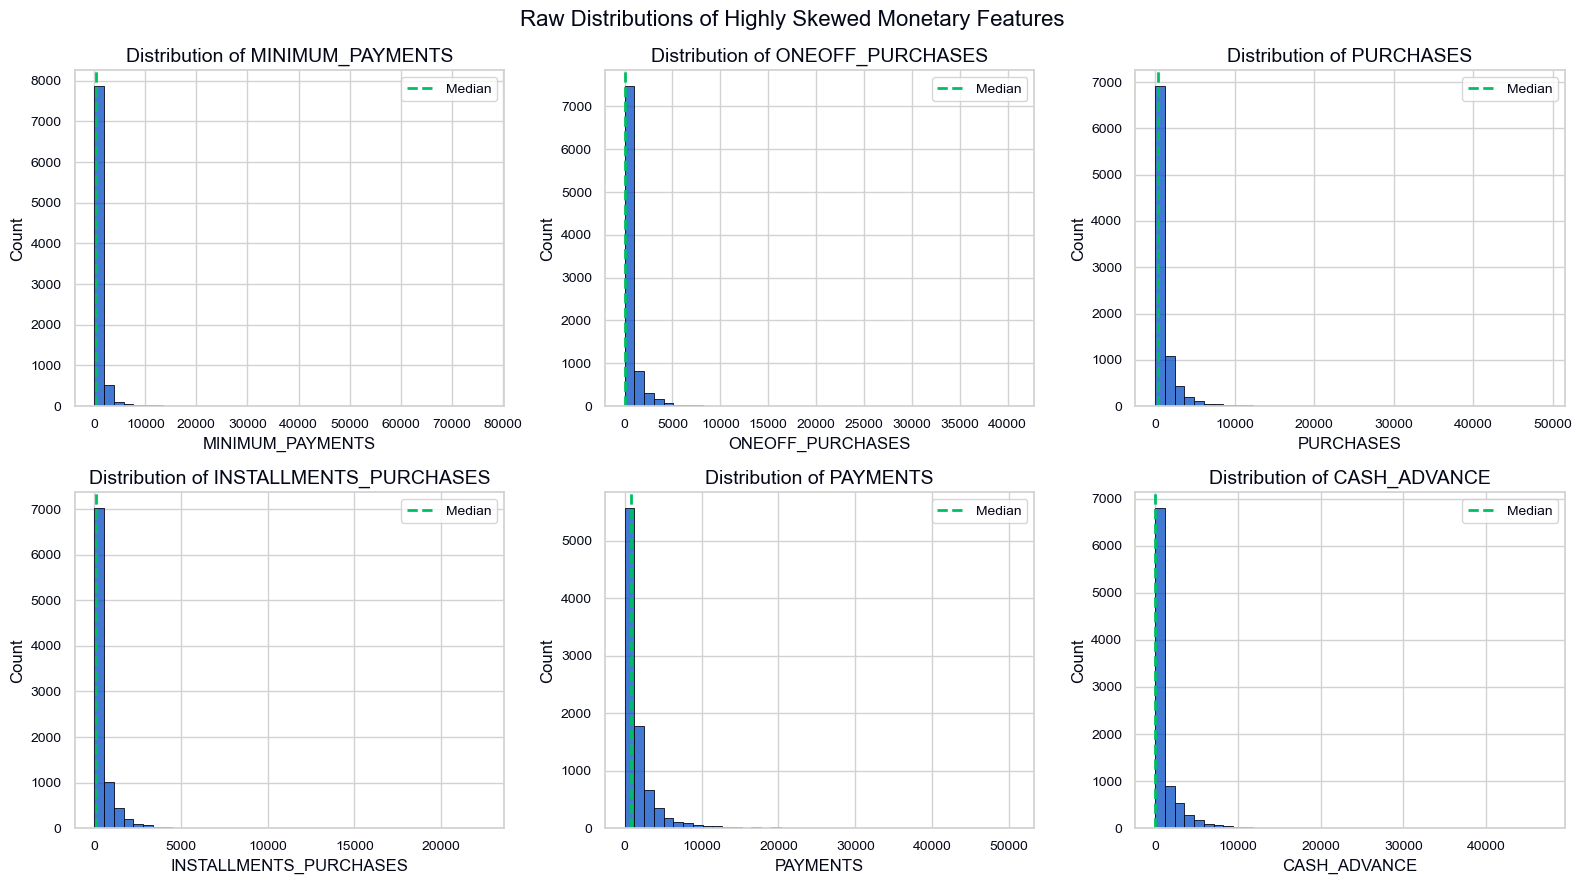

In [13]:
# Select the most important skewed monetary features for visual inspection
skewed_features_to_plot = [
    "MINIMUM_PAYMENTS",
    "ONEOFF_PURCHASES",
    "PURCHASES",
    "INSTALLMENTS_PURCHASES",
    "PAYMENTS",
    "CASH_ADVANCE"]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 9))
axes = axes.flatten()
for ax, feature in zip(axes, skewed_features_to_plot):
    sns.histplot(
        data=df,
        x=feature,
        bins=40,
        color=PROJECT_COLORS["primary_blue"],
        edgecolor=PROJECT_COLORS["deep_navy"],
        ax=ax)
    ax.axvline(
        df[feature].median(),
        color=PROJECT_COLORS["green"],
        linestyle="--",
        linewidth=2,
        label="Median")
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")
    ax.legend()

fig.suptitle("Raw Distributions of Highly Skewed Monetary Features", fontsize=16)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "02_raw_distributions_skewed_monetary_features.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

In [17]:
corr_matrix = df[numeric_cols].corr()
corr_matrix

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
BALANCE,1.0000,0.3224,0.1813,0.1643,0.1265,0.4967,-0.0779,0.0732,-0.0632,0.4492,0.3852,0.1543,0.5313,0.3228,0.3987,-0.3190,0.0727
BALANCE_FREQUENCY,0.3224,1.0000,0.1337,0.1043,0.1243,0.0994,0.2297,0.2024,0.1761,0.1919,0.1416,0.1896,0.0958,0.0650,0.1326,-0.0951,0.1198
PURCHASES,0.1813,0.1337,1.0000,0.9168,0.6799,-0.0515,0.3930,0.4984,0.3156,-0.1201,-0.0672,0.6896,0.3570,0.6033,0.0939,0.1804,0.0863
ONEOFF_PURCHASES,0.1643,0.1043,0.9168,1.0000,0.3306,-0.0313,0.2649,0.5249,0.1277,-0.0826,-0.0462,0.5455,0.3197,0.5673,0.0488,0.1328,0.0642
INSTALLMENTS_PURCHASES,0.1265,0.1243,0.6799,0.3306,1.0000,-0.0642,0.4424,0.2140,0.5114,-0.1323,-0.0740,0.6281,0.2565,0.3841,0.1322,0.1826,0.0861
CASH_ADVANCE,0.4967,0.0994,-0.0515,-0.0313,-0.0642,1.0000,-0.2155,-0.0868,-0.1771,0.6285,0.6565,-0.0759,0.3040,0.4532,0.1401,-0.1529,-0.0683
PURCHASES_FREQUENCY,-0.0779,0.2297,0.3930,0.2649,0.4424,-0.2155,1.0000,0.5013,0.8629,-0.3085,-0.2035,0.5684,0.1198,0.1035,0.0030,0.3058,0.0615
ONEOFF_PURCHASES_FREQUENCY,0.0732,0.2024,0.4984,0.5249,0.2140,-0.0868,0.5013,1.0000,0.1423,-0.1117,-0.0691,0.5449,0.2950,0.2435,-0.0303,0.1575,0.0825
PURCHASES_INSTALLMENTS_FREQUENCY,-0.0632,0.1761,0.3156,0.1277,0.5114,-0.1771,0.8629,0.1423,1.0000,-0.2630,-0.1692,0.5300,0.0608,0.0856,0.0301,0.2501,0.0733
CASH_ADVANCE_FREQUENCY,0.4492,0.1919,-0.1201,-0.0826,-0.1323,0.6285,-0.3085,-0.1117,-0.2630,1.0000,0.7996,-0.1312,0.1326,0.1832,0.0988,-0.2498,-0.1334


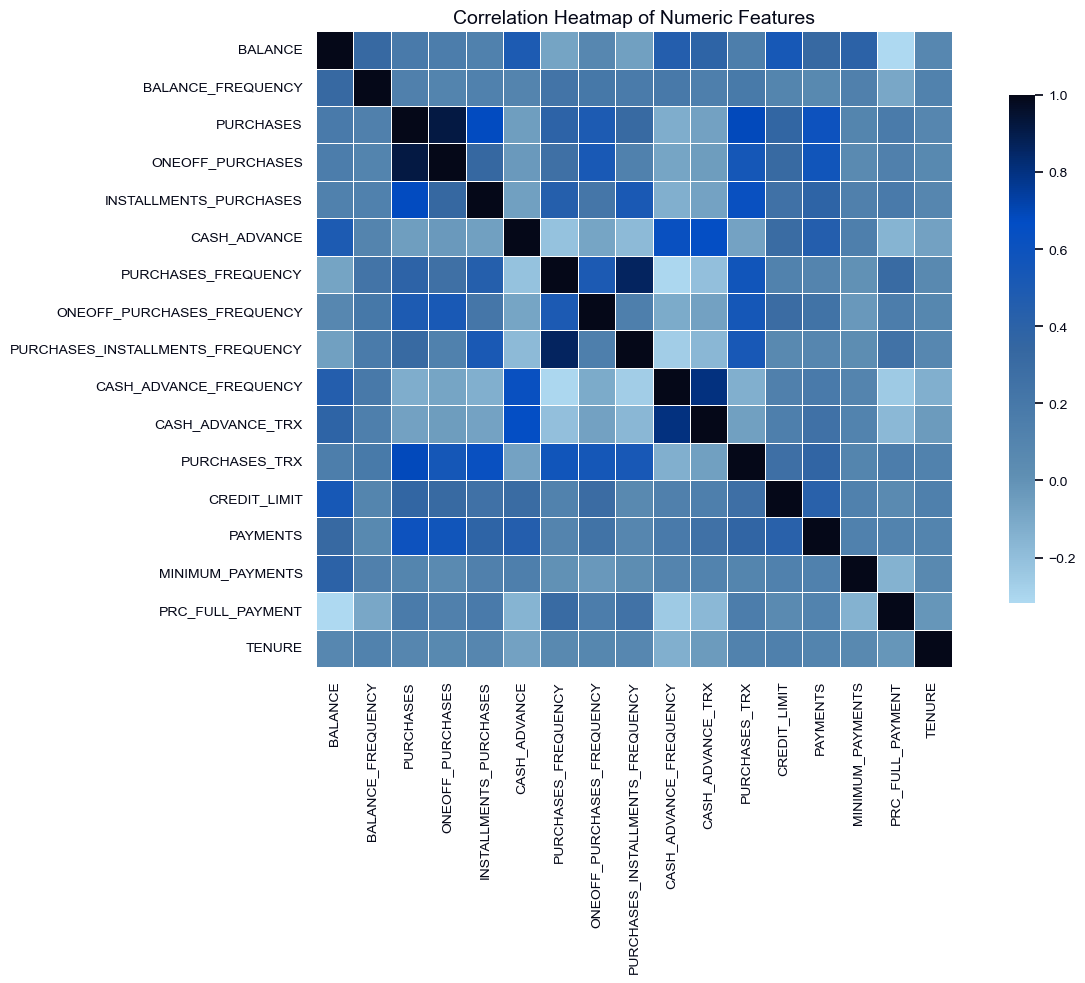

In [18]:
# Create a heatmap to inspect correlations between numeric features
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap=BLUE_CMAP,
    annot=False,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "04_correlation_heatmap_numeric_features.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

In [19]:
# Set a correlation threshold for identifying potentially redundant pairs
corr_threshold = 0.70

# Keep only the upper triangle of the correlation matrix to avoid duplicate pairs
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Convert the upper triangle into a long table of feature pairs
high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index())

high_corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
high_corr_pairs["abs_correlation"] = high_corr_pairs["correlation"].abs()
high_corr_pairs = high_corr_pairs[high_corr_pairs["abs_correlation"] >= corr_threshold].sort_values("abs_correlation", ascending=False)
high_corr_pairs

,feature_1,feature_2,correlation,abs_correlation
37,PURCHASES,ONEOFF_PURCHASES,0.9168,0.9168
110,PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,0.8629,0.8629
163,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,0.7996,0.7996


In [22]:
# Build a feature watchlist table for all numeric features

# Define working thresholds for the analysis phase
ZERO_HEAVY_THRESHOLD = 40.0
HIGH_SKEW_THRESHOLD = 2.0
HIGH_CORR_THRESHOLD = 0.70

# Calculate missing percentage for each numeric feature
missing_pct = df[numeric_cols].isna().mean().mul(100)

# Calculate zero percentage for each numeric feature
zero_pct = (df[numeric_cols] == 0).mean().mul(100)

# Calculate skewness and absolute skewness for each numeric feature
skewness_values = df[numeric_cols].skew()
abs_skewness_values = skewness_values.abs()

# Create a writable absolute-correlation matrix
abs_corr_matrix = corr_matrix.abs().copy()
abs_corr_values = abs_corr_matrix.to_numpy(copy=True)

# Replace self-correlation values on the diagonal with zero
np.fill_diagonal(abs_corr_values, 0)

# Convert the writable NumPy array back to a DataFrame
abs_corr_matrix = pd.DataFrame(abs_corr_values, index=abs_corr_matrix.index, columns=abs_corr_matrix.columns)

# Compute the maximum absolute correlation for each feature
max_abs_correlation = abs_corr_matrix.max(axis=1)

# Identify the paired feature with the highest absolute correlation
paired_feature = abs_corr_matrix.idxmax(axis=1)

# Create the base watchlist table
feature_watchlist = pd.DataFrame({
    "feature": numeric_cols,
    "missing_pct": missing_pct.values,
    "zero_pct": zero_pct.values,
    "skewness": skewness_values.values,
    "abs_skewness": abs_skewness_values.values,
    "max_abs_correlation": max_abs_correlation.values,
    "paired_feature": paired_feature.values})

# Create boolean flags based on the selected thresholds
feature_watchlist["has_missing"] = feature_watchlist["missing_pct"] > 0
feature_watchlist["zero_heavy"] = feature_watchlist["zero_pct"] >= ZERO_HEAVY_THRESHOLD
feature_watchlist["highly_skewed"] = feature_watchlist["abs_skewness"] >= HIGH_SKEW_THRESHOLD
feature_watchlist["highly_correlated"] = feature_watchlist["max_abs_correlation"] >= HIGH_CORR_THRESHOLD

# Create a simple score to rank features that need more attention
feature_watchlist["watchlist_score"] = (
    feature_watchlist["has_missing"].astype(int)
    + feature_watchlist["zero_heavy"].astype(int)
    + feature_watchlist["highly_skewed"].astype(int)
    + feature_watchlist["highly_correlated"].astype(int))

# Create a summary recommendation for each feature
feature_watchlist["action_hint"] = np.select(
    [
        feature_watchlist["has_missing"] & feature_watchlist["highly_skewed"],
        feature_watchlist["zero_heavy"] & feature_watchlist["highly_skewed"] & feature_watchlist["highly_correlated"],
        feature_watchlist["zero_heavy"] & feature_watchlist["highly_skewed"],
        feature_watchlist["highly_correlated"],
        feature_watchlist["zero_heavy"],
        feature_watchlist["highly_skewed"],
        feature_watchlist["has_missing"]
    ],
    [
        "Impute and review transformation",
        "High-priority review",
        "Review transformation carefully",
        "Correlation watchlist",
        "Sparse behavior feature",
        "Candidate for transformation",
        "Imputation needed"
    ],
    default="Keep in baseline pipeline")

# Sort features so the most important review candidates appear first
feature_watchlist = feature_watchlist.sort_values(
    by=["watchlist_score", "abs_skewness", "zero_pct", "max_abs_correlation"],
    ascending=[False, False, False, False]
).reset_index(drop=True)
feature_watchlist

,feature,missing_pct,zero_pct,skewness,abs_skewness,max_abs_correlation,paired_feature,has_missing,zero_heavy,highly_skewed,highly_correlated,watchlist_score,action_hint
0,ONEOFF_PURCHASES,0.0000,48.0670,10.0451,10.0451,0.9168,PURCHASES,False,True,True,True,3,High-priority review
1,CASH_ADVANCE_TRX,0.0000,51.7095,5.7213,5.7213,0.7996,CASH_ADVANCE_FREQUENCY,False,True,True,True,3,High-priority review
2,MINIMUM_PAYMENTS,3.4972,0.0000,13.6228,13.6228,0.3987,BALANCE,True,False,True,False,2,Impute and review transformation
3,PURCHASES,0.0000,22.8380,8.1443,8.1443,0.9168,ONEOFF_PURCHASES,False,False,True,True,2,Correlation watchlist
4,INSTALLMENTS_PURCHASES,0.0000,43.7542,7.2991,7.2991,0.6799,PURCHASES,False,True,True,False,2,Review transformation carefully
5,CASH_ADVANCE,0.0000,51.7095,5.1666,5.1666,0.6565,CASH_ADVANCE_TRX,False,True,True,False,2,Review transformation carefully
6,CASH_ADVANCE_FREQUENCY,0.0000,51.7095,1.8287,1.8287,0.7996,CASH_ADVANCE_TRX,False,True,False,True,2,Correlation watchlist
7,PURCHASES_INSTALLMENTS_FREQUENCY,0.0000,43.7430,0.5092,0.5092,0.8629,PURCHASES_FREQUENCY,False,True,False,True,2,Correlation watchlist
8,PAYMENTS,0.0000,2.6816,5.9076,5.9076,0.6033,PURCHASES,False,False,True,False,1,Candidate for transformation
9,PURCHASES_TRX,0.0000,22.8380,4.6307,4.6307,0.6896,PURCHASES,False,False,True,False,1,Candidate for transformation


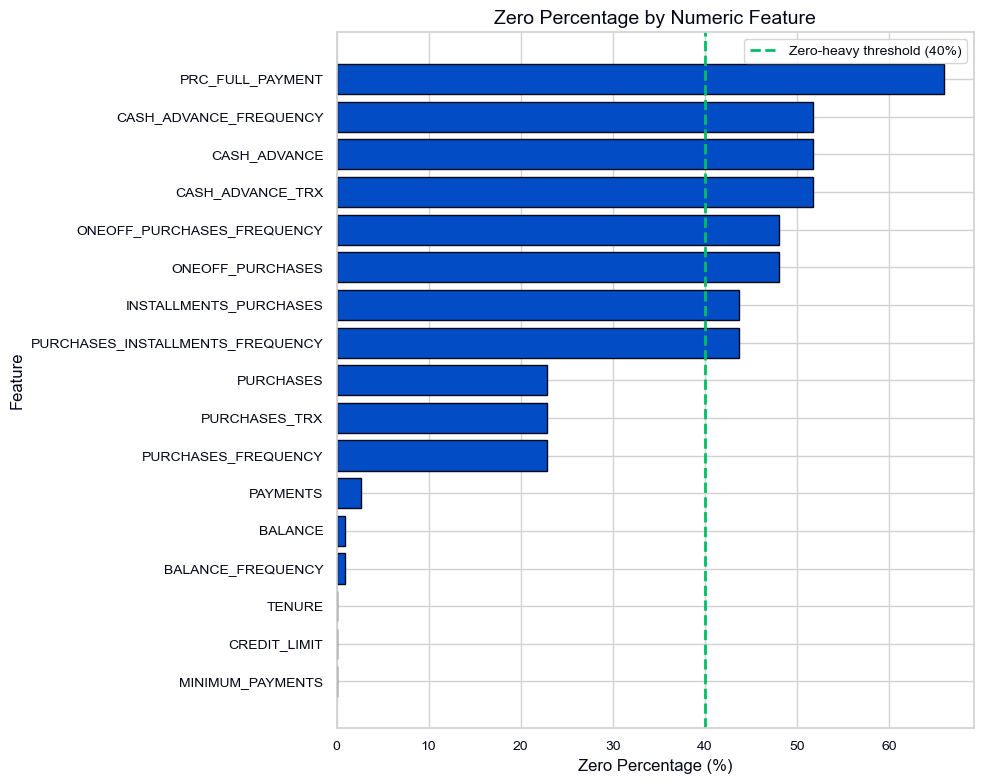

In [23]:
# Sort features by zero percentage from lowest to highest for a cleaner horizontal plot
zero_summary_plot = zero_summary.sort_values("zero_pct", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(
    y=zero_summary_plot.index,
    width=zero_summary_plot["zero_pct"],
    color=PROJECT_COLORS["primary_blue"],
    edgecolor=PROJECT_COLORS["deep_navy"])
plt.axvline(
    x=40,
    color=PROJECT_COLORS["green"],
    linestyle="--",
    linewidth=2,
    label="Zero-heavy threshold (40%)")
plt.title("Zero Percentage by Numeric Feature")
plt.xlabel("Zero Percentage (%)")
plt.ylabel("Feature")
plt.legend()
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "05_zero_percentage_by_feature.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

## Audit Summary

This initial audit shows that the dataset is structurally clean and suitable for clustering, but it also highlights several preprocessing risks that should not be ignored.

### Key findings

- The dataset contains **8,950 observations** and **18 columns**, including **1 customer identifier (`CUST_ID`)** and **17 numeric behavioral features**.
- No **duplicate rows** or **duplicate customer IDs** were found.
- Missing values are limited to:
  - `MINIMUM_PAYMENTS` (~3.50%)
  - `CREDIT_LIMIT` (~0.01%)

### Distribution and sparsity issues

- Several behavioral variables are **zero-heavy**, especially:
  - `PRC_FULL_PAYMENT`
  - `CASH_ADVANCE`
  - `CASH_ADVANCE_FREQUENCY`
  - `CASH_ADVANCE_TRX`
  - `ONEOFF_PURCHASES`
  - `ONEOFF_PURCHASES_FREQUENCY`
- Multiple monetary features are **strongly right-skewed**, with long tails and extreme values. The most affected variables include:
  - `MINIMUM_PAYMENTS`
  - `ONEOFF_PURCHASES`
  - `PURCHASES`
  - `INSTALLMENTS_PURCHASES`
  - `PAYMENTS`
  - `CASH_ADVANCE`

### Correlation structure

- A few feature pairs show strong positive correlation, most notably:
  - `PURCHASES` and `ONEOFF_PURCHASES`
  - `PURCHASES_FREQUENCY` and `PURCHASES_INSTALLMENTS_FREQUENCY`
  - `CASH_ADVANCE_FREQUENCY` and `CASH_ADVANCE_TRX`
- However, the dataset does **not** appear to suffer from widespread redundancy across all variables.

### Implications for preprocessing

The audit suggests that clustering should **not** be performed on the raw feature space without preprocessing.

Two preprocessing paths will be explored later:

1. **Baseline pipeline**
   - imputation
   - scaling
   - original numeric features

2. **Enhanced pipeline**
   - imputation
   - selective transformation of highly skewed variables
   - scaling
   - possible feature review if modeling results justify it

### Conclusion

Overall, the dataset is usable for customer segmentation, but it clearly requires careful preprocessing due to:
- limited missingness,
- high zero concentration in several behavioral features,
- strong skewness in key monetary variables,
- and a small number of potentially overlapping feature pairs.

These findings will directly inform the modeling strategy in the next phase.